In [1]:
import MetaTrader5 as mt5
import pandas as pd
import time
from datetime import datetime, timedelta
import ta
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

plt.style.use('dark_background')

In [88]:

mt5.initialize()

symbols = ['XAUUSD','EURUSD', 'GBPUSD', 'AUDUSD', 'NZDUSD', 'XAGUSD']
timeframe = mt5.TIMEFRAME_D1
start_date = datetime(2022, 1, 1)
end_time = datetime.now()
    
def get_data(symbol, timeframe, start_date, end_time):
    rates = mt5.copy_rates_range(symbol, timeframe, start_date, end_time)
    df = pd.DataFrame(rates)
    df = df[['time','close']]
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)
    return df

def multiple_pairs_data(symbols):
    symbols_data = {}
    for symbol in symbols:
        symbols_data[symbol] = get_data(symbol, timeframe, start_date, end_time)
    # Concatenate data for each symbol into a single DataFrame
    symbols_data_concatenated = pd.concat(symbols_data, axis=1)
    return symbols_data_concatenated

symbols_data_concatenated = multiple_pairs_data(symbols)
symbols_data_concatenated


,XAUUSD,EURUSD,GBPUSD,AUDUSD,NZDUSD,XAGUSD
,close,close,close,close,close,close
time,,,,,,
2022-01-03,1801.20,1.12971,1.34786,0.71905,0.67857,22.880
2022-01-04,1814.36,1.12862,1.35281,0.72403,0.68078,23.041
2022-01-05,1810.53,1.13135,1.35539,0.72213,0.67957,22.783
2022-01-06,1789.72,1.12976,1.35313,0.71616,0.67476,22.167
2022-01-07,1796.30,1.13590,1.35903,0.71812,0.67748,22.314
...,...,...,...,...,...,...
2024-08-02,2441.32,1.09102,1.28036,0.65109,0.59563,28.529
2024-08-05,2409.42,1.09504,1.27732,0.64957,0.59389,27.204


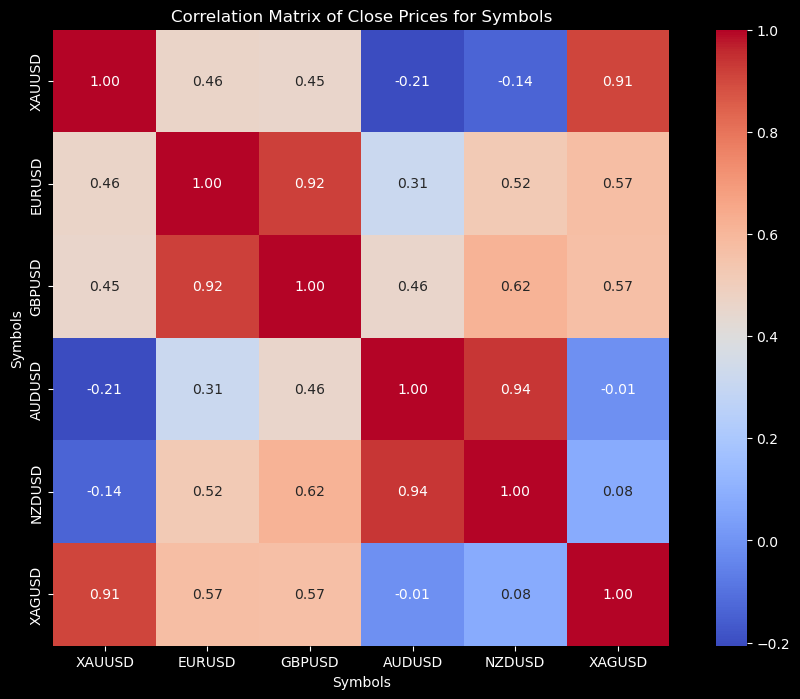

In [89]:
# Extract close prices for each symbol
close_prices = symbols_data_concatenated.xs('close', axis=1, level=1)

# Calculate correlation matrix
correlation_matrix = close_prices.corr()

# Plot correlation matrix as heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Matrix of Close Prices for Symbols')
plt.xlabel('Symbols')
plt.ylabel('Symbols')
plt.show()

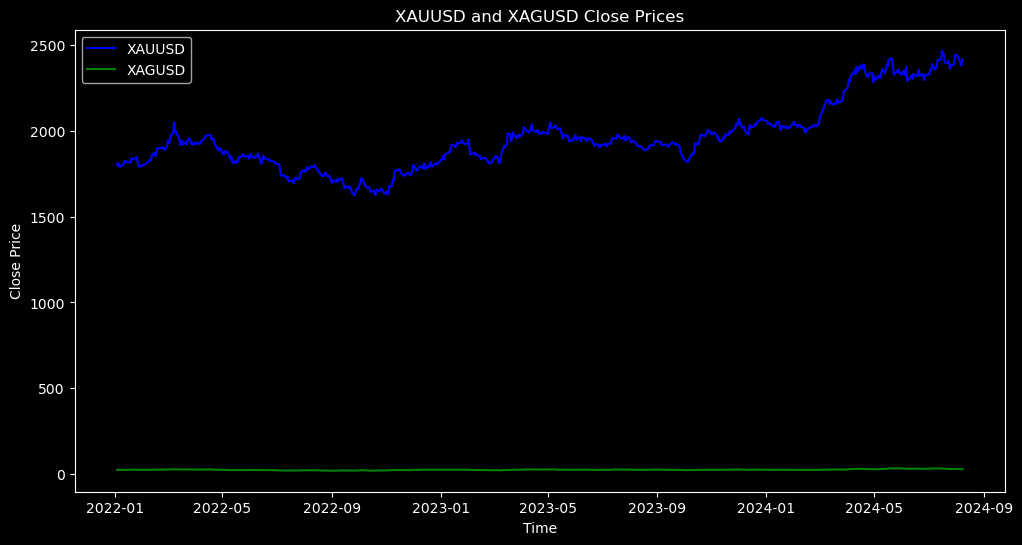

In [90]:
symbol1_name = 'XAUUSD'
symbol2_name = 'XAGUSD'

# Extract close prices for GBPJPY and USDJPY
symbol1 = symbols_data_concatenated[symbol1_name]['close'].dropna()
symbol2 = symbols_data_concatenated[symbol2_name]['close'].dropna()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(symbol1.index, symbol1.values, label= symbol1_name, color='blue')
plt.plot(symbol2.index, symbol2.values, label=symbol2_name, color='green')
plt.title(f'{symbol1_name} and {symbol2_name} Close Prices')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.grid(False)
plt.show()


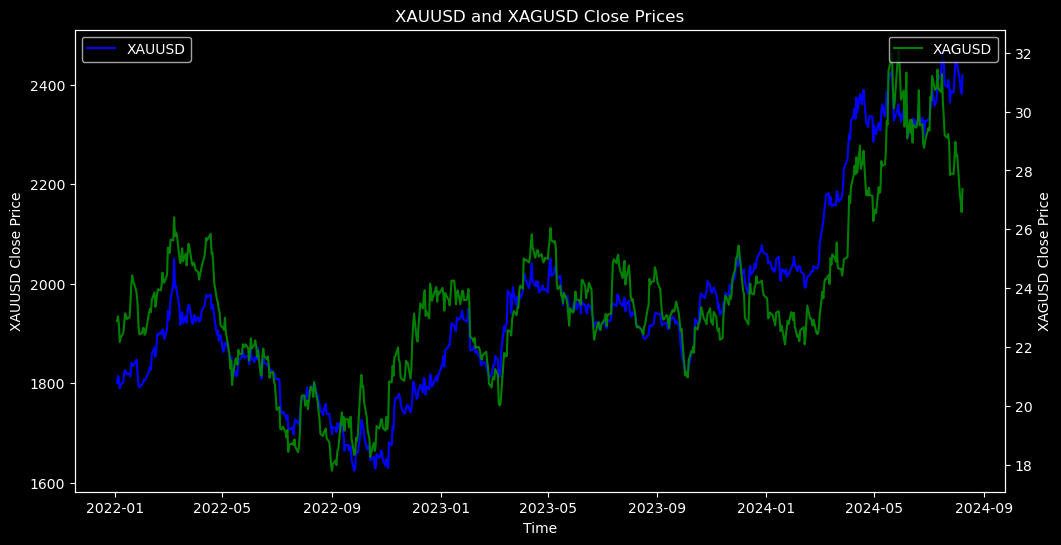

In [91]:

# Create figure and axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot GBPJPY on the first axis
ax1.plot(symbol1.index, symbol1.values, label=symbol1_name, color='blue')
ax1.set_xlabel('Time')
ax1.set_ylabel(f'{symbol1_name} Close Price')
ax1.tick_params('y')

# Create a twin Axes sharing the same x-axis
ax2 = ax1.twinx()

# Plot USDJPY on the second axis
ax2.plot(symbol2.index, symbol2.values, label=symbol2_name, color='green')
ax2.set_ylabel(f'{symbol2_name} Close Price')
ax2.tick_params('y')

# Add legend
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title(f'{symbol1_name} and {symbol2_name} Close Prices')
plt.grid(False)
plt.show()


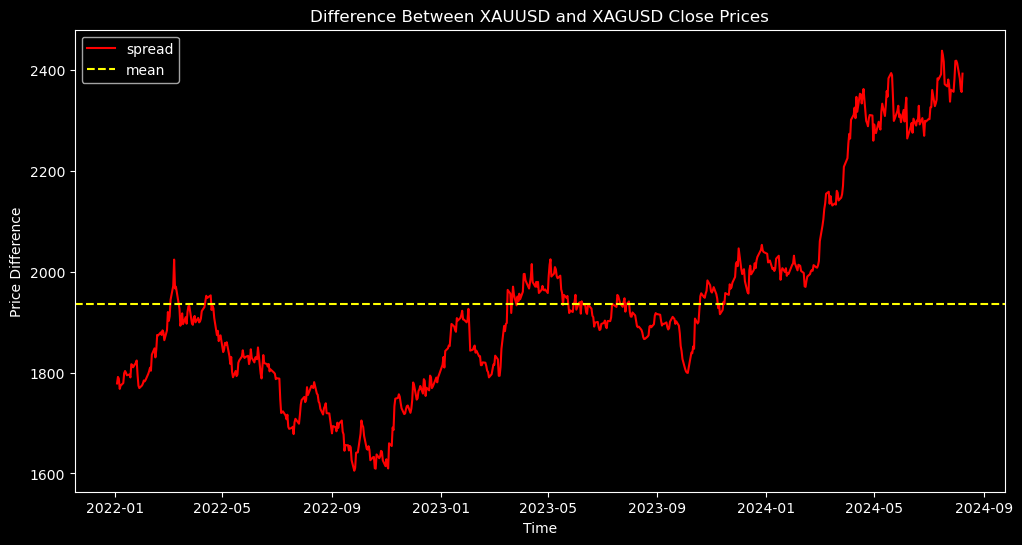

In [92]:
# Calculate the difference between USDJPY and GBPJPY close prices
price_diff = symbol1 - symbol2

price_diff = price_diff.dropna()

# Plotting the difference
plt.figure(figsize=(12, 6))
plt.plot(price_diff.index, price_diff.values, label=f'Difference ({symbol1_name} - {symbol2_name})', color='red')
plt.axhline(price_diff.mean(), color = 'yellow', linestyle = '--')
plt.title(f'Difference Between {symbol1_name} and {symbol2_name} Close Prices')
plt.xlabel('Time')
plt.ylabel('Price Difference')
plt.legend(['spread', 'mean'])
plt.grid(False)
plt.show()

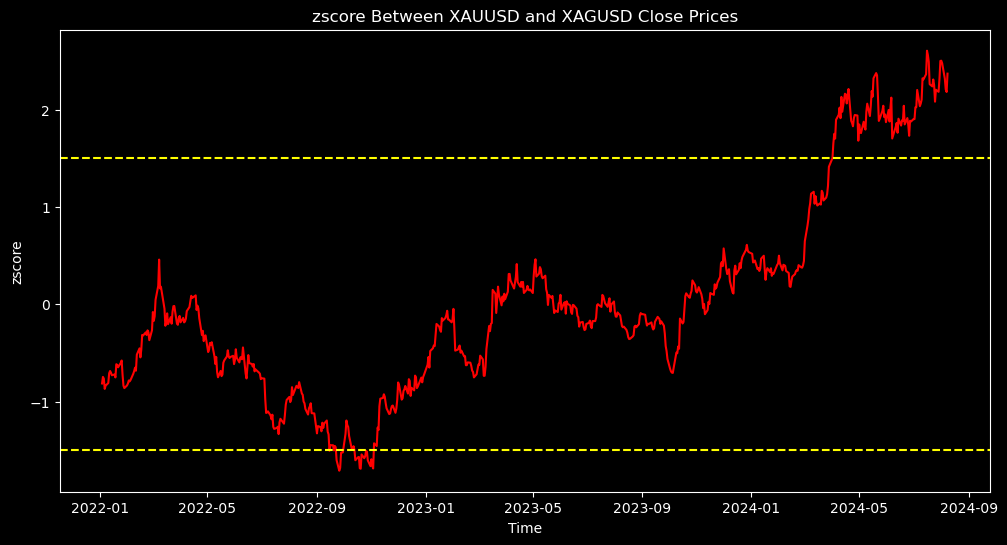

In [93]:
# Calculate mean and standard deviation
mu = price_diff.mean()
sigma = price_diff.std()

# Calculate Z-score for each data point
z_scores = (price_diff - mu) / sigma


# Plotting the difference
plt.figure(figsize=(12, 6))
plt.plot(z_scores.index, z_scores.values, label=f'z score ({symbol1_name} - {symbol2_name})', color='red')
plt.axhline(y = 1.5, color = 'yellow', linestyle = '--')
plt.axhline(y = -1.5, color = 'yellow', linestyle = '--')
plt.title(f'zscore Between {symbol1_name} and {symbol2_name} Close Prices')
plt.xlabel('Time')
plt.ylabel('zscore')
plt.grid(False)
plt.show()

In [94]:
z_scores

time
2022-01-03   -0.812482
2022-01-04   -0.745079
2022-01-05   -0.763601
2022-01-06   -0.868311
2022-01-07   -0.834954
                ...   
2024-08-02    2.477390
2024-08-05    2.318851
2024-08-06    2.209340
2024-08-07    2.181765
2024-08-08    2.370336
Name: close, Length: 672, dtype: float64

In [95]:
normalised1 = (symbol1 - symbol1.mean()) / symbol1.std()
normalised2 = (symbol2 - symbol2.mean()) / symbol2.std()

diff = normalised2 - normalised1
diff

time
2022-01-03    0.576001
2022-01-04    0.564854
2022-01-05    0.494415
2022-01-06    0.385921
2022-01-07    0.403554
                ...   
2024-08-02   -0.727738
2024-08-05   -1.026910
2024-08-06   -1.015132
2024-08-07   -1.105521
2024-08-08   -1.022350
Name: close, Length: 672, dtype: float64